# Preliminary Testing for EMNIST
- First implementation: Sequential Model using the balanced EMNIST dataset

In [131]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import cv2
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import tensorflow as tf

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras import layers
from tensorflow.keras.layers import *
from tensorflow.keras.utils import to_categorical


from tqdm import tqdm
import kagglehub
import os

In [132]:
import kagglehub
import os

path = kagglehub.dataset_download("crawford/emnist")
print(os.listdir(path))
# kaggle link: https://www.kaggle.com/datasets/crawford/emnist/data

train_df = pd.read_csv(f'{path}/emnist-balanced-train.csv', header=None) # note: balanced
train_df.head()

['emnist-letters-test.csv', 'emnist-mnist-train.csv', 'emnist-mnist-test.csv', 'emnist-byclass-train.csv', 'emnist-letters-train.csv', 'emnist-digits-train.csv', 'emnist-digits-mapping.txt', 'emnist-balanced-train.csv', 'emnist-byclass-mapping.txt', 'emnist-digits-test.csv', 'emnist-bymerge-train.csv', 'emnist-letters-mapping.txt', 'emnist-bymerge-mapping.txt', 'emnist-balanced-mapping.txt', 'emnist-bymerge-test.csv', 'emnist_source_files', 'emnist-byclass-test.csv', 'emnist-mnist-mapping.txt', 'emnist-balanced-test.csv']


,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,784
0,45,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,36,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,43,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,15,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [133]:
train_csv = os.path.join(path, 'emnist-balanced-train.csv')
test_csv = os.path.join(path, 'emnist-balanced-test.csv')

train_df = pd.read_csv(train_csv, header=None)
test_df = pd.read_csv(test_csv, header=None)

In [134]:
print(train_df.shape)
print(test_df.shape)
print(train_df.head())

(112800, 785)
(18800, 785)
   0    1    2    3    4    5    6    7    8    9    ...  775  776  777  778  \
0   45    0    0    0    0    0    0    0    0    0  ...    0    0    0    0   
1   36    0    0    0    0    0    0    0    0    0  ...    0    0    0    0   
2   43    0    0    0    0    0    0    0    0    0  ...    0    0    0    0   
3   15    0    0    0    0    0    0    0    0    0  ...    0    0    0    0   
4    4    0    0    0    0    0    0    0    0    0  ...    0    0    0    0   

   779  780  781  782  783  784  
0    0    0    0    0    0    0  
1    0    0    0    0    0    0  
2    0    0    0    0    0    0  
3    0    0    0    0    0    0  
4    0    0    0    0    0    0  

[5 rows x 785 columns]


In [135]:
train_df.shape

(112800, 785)

In [136]:
X_train = train_df.loc[:, 1:]
y_train = train_df.loc[:, 0]

X_train.shape, y_train.shape

((112800, 784), (112800,))

In [137]:
y_train.head()

0    45
1    36
2    43
3    15
4     4
Name: 0, dtype: int64

In [138]:
MAPPING_PATH = os.path.join(path, 'emnist-balanced-mapping.txt')
label_map = pd.read_csv(
    # "/kaggle/input/emnist/emnist-balanced-mapping.txt",
    MAPPING_PATH,
    delimiter=' ',
    index_col=0,
    header=None
).iloc[:, 0]   # prend la première colonne comme Series

label_map.head()

0
0    48
1    49
2    50
3    51
4    52
Name: 1, dtype: int64

In [139]:
label_dictionary = {}
for index, label in enumerate(label_map):
    label_dictionary[index] = chr(label)

label_dictionary

{0: '0',
 1: '1',
 2: '2',
 3: '3',
 4: '4',
 5: '5',
 6: '6',
 7: '7',
 8: '8',
 9: '9',
 10: 'A',
 11: 'B',
 12: 'C',
 13: 'D',
 14: 'E',
 15: 'F',
 16: 'G',
 17: 'H',
 18: 'I',
 19: 'J',
 20: 'K',
 21: 'L',
 22: 'M',
 23: 'N',
 24: 'O',
 25: 'P',
 26: 'Q',
 27: 'R',
 28: 'S',
 29: 'T',
 30: 'U',
 31: 'V',
 32: 'W',
 33: 'X',
 34: 'Y',
 35: 'Z',
 36: 'a',
 37: 'b',
 38: 'd',
 39: 'e',
 40: 'f',
 41: 'g',
 42: 'h',
 43: 'n',
 44: 'q',
 45: 'r',
 46: 't'}

In [140]:
sample_image = X_train.iloc[40]
sample_label = y_train.iloc[40]
sample_image.shape, sample_label

((784,), np.int64(25))

Label entry 42: P


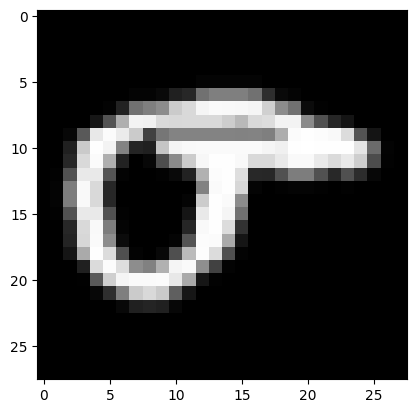

In [141]:
W = 28
H = 28
print("Label entry 42:", label_dictionary[sample_label])
plt.imshow(sample_image.values.reshape(W, H), cmap=plt.cm.gray)
plt.show()

Label entry 42: P


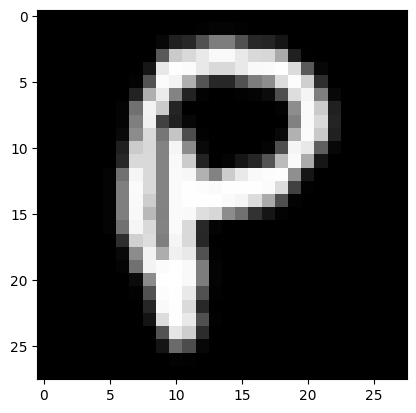

In [142]:
def reshape_and_rotate(image):
    W = 28
    H = 28
    image = image.reshape(W, H)
    image = np.fliplr(image)
    image = np.rot90(image)
    return image

print("Label entry 42:", label_dictionary[sample_label])
plt.imshow(reshape_and_rotate(sample_image.values), cmap=plt.cm.gray)
plt.show()

In [143]:
X_train = np.apply_along_axis(reshape_and_rotate, 1, X_train.values)
X_train.shape

(112800, 28, 28)

In [144]:
X_train = X_train.astype('float32') / 255

In [145]:
number_of_classes = y_train.nunique()
number_of_classes
y_train = to_categorical(y_train, number_of_classes)
y_train.shape

(112800, 47)

In [146]:
y_train[200]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.])

In [147]:
X_train = X_train.reshape(-1, W, H, 1)
X_train.shape

(112800, 28, 28, 1)

In [148]:
X_train, X_val, y_train, y_val = train_test_split(X_train, 
                                                  y_train, 
                                                  test_size= 0.2, 
                                                  random_state=102)

In [149]:
model = Sequential()

model.add(layers.Conv2D(filters=32, kernel_size=(5,5), padding='same', activation='relu', input_shape=(W, H, 1)))
model.add(layers.MaxPool2D(strides=2))
model.add(layers.Conv2D(filters=64, kernel_size=(5,5), padding='valid', activation='relu'))
model.add(layers.MaxPool2D(strides=2))
model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dense(number_of_classes, activation='softmax'))
model.summary()

/Users/rothpitoupoeung/Desktop/IS_TEST/env/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 10, 10, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 47)             │         6,063 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 263,087 (1.00 MB)

 Trainable params: 263,087 (1.00 MB)

 Non-trainable params: 0 (0.00 B)

In [150]:
optimizer_name = 'adam'

model.compile(loss='categorical_crossentropy', optimizer=optimizer_name, metrics=['accuracy'])

early_stopping = EarlyStopping(monitor='val_loss', patience=5, verbose=1, mode='min')
mcp_save = ModelCheckpoint('my_model.keras', save_best_only=True, monitor='val_loss', verbose=1, mode='auto')
history = model.fit(X_train,
                    y_train, 
                    epochs=10, # original: 10
                    batch_size=32, 
                    verbose=1, 
                    validation_split=0.2,
                    callbacks=[early_stopping, mcp_save])

Epoch 1/10
2256/2256 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6655 - loss: 1.1500
Epoch 1: val_loss improved from None to 0.43308, saving model to my_model.keras
2256/2256 ━━━━━━━━━━━━━━━━━━━━ 23s 10ms/step - accuracy: 0.7776 - loss: 0.7059 - val_accuracy: 0.8561 - val_loss: 0.4331
Epoch 2/10
2252/2256 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8605 - loss: 0.3978
Epoch 2: val_loss improved from 0.43308 to 0.37679, saving model to my_model.keras
2256/2256 ━━━━━━━━━━━━━━━━━━━━ 24s 11ms/step - accuracy: 0.8615 - loss: 0.3948 - val_accuracy: 0.8683 - val_loss: 0.3768
Epoch 3/10
2251/2256 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8785 - loss: 0.3319
Epoch 3: val_loss improved from 0.37679 to 0.37264, saving model to my_model.keras
2256/2256 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - accuracy: 0.8788 - loss: 0.3330 - val_accuracy: 0.8703 - val_loss: 0.3726
Epoch 4/10
2255/2256 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8894 - loss: 0.2913
Epoch 4: val_loss improved from 0.37264

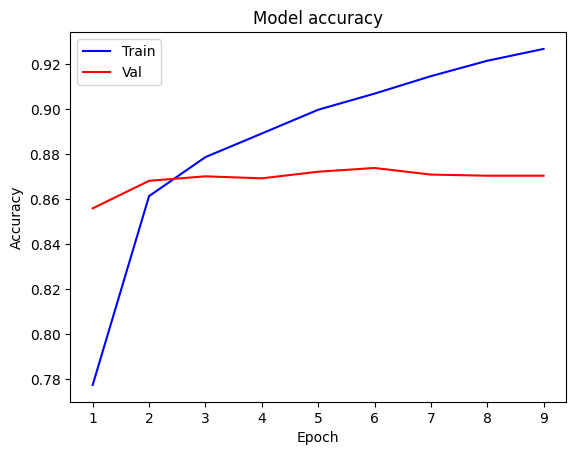

In [151]:
def plotgraph(epochs, acc, val_acc):
    # Plot training & validation accuracy values
    plt.plot(epochs, acc, 'b')
    plt.plot(epochs, val_acc, 'r')
    plt.title('Model accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Val'], loc='upper left')
    plt.show()
    
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1,len(acc)+1)
# Accuracy curve
plotgraph(epochs, acc, val_acc)

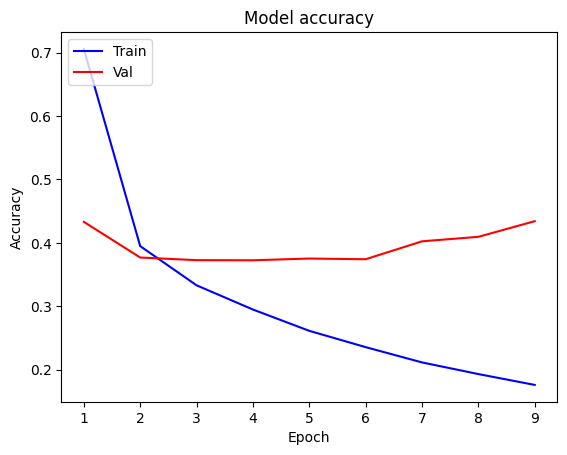

In [152]:
plotgraph(epochs, loss, val_loss)

In [153]:
y_pred = model.predict(X_val)
y_pred.shape

705/705 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


(22560, 47)

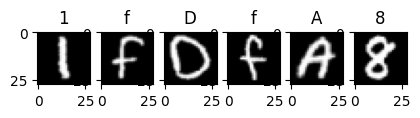

In [154]:
for i in range(10, 16):
    plt.subplot(380 + (i%10+1))
    plt.imshow(X_val[i].reshape(28, 28), cmap=plt.cm.gray)
    plt.title(label_dictionary[y_pred[i].argmax()])

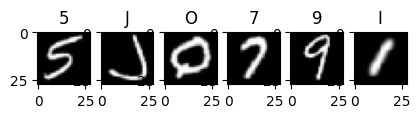

In [155]:
for i in range(72, 78):
    plt.subplot(380 + (i%10+1))
    plt.imshow(X_val[i].reshape(28, 28), cmap=plt.cm.gray)
    plt.title(label_dictionary[y_pred[i].argmax()])

In [156]:
model.evaluate(X_val, y_val)

705/705 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8674 - loss: 0.4409


[0.44090402126312256, 0.867375910282135]

In [157]:
# test_df = pd.read_csv('/kaggle/input/emnist/emnist-balanced-test.csv', header=None)
test_df.shape

(18800, 785)

In [158]:
test_df.describe()

,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,784
count,18800.000000,18800.0,18800.0,18800.0,18800.0,18800.000000,18800.000000,18800.000000,18800.000000,18800.000000,...,18800.0,18800.0,18800.0,18800.0,18800.0,18800.0,18800.0,18800.0,18800.0,18800.0
mean,23.000000,0.0,0.0,0.0,0.0,0.006064,0.019734,0.011277,0.009362,0.011277,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
std,13.565021,0.0,0.0,0.0,0.0,0.528828,1.761298,1.054441,0.892318,1.517275,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
min,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,11.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
50%,23.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
75%,35.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,46.000000,0.0,0.0,0.0,0.0,63.000000,213.000000,108.000000,95.000000,208.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [159]:
X_test = test_df.loc[:, 1:]
y_test = test_df.loc[:, 0]

X_test.shape, y_test.shape

((18800, 784), (18800,))

In [160]:
X_test = np.apply_along_axis(reshape_and_rotate, 1, X_test.values)
y_test = to_categorical(y_test, number_of_classes)

X_test.shape, y_test.shape

((18800, 28, 28), (18800, 47))

In [161]:
X_test = X_test.astype('float32') / 255
X_test = X_test.reshape(-1, W, H, 1)
X_test.shape

(18800, 28, 28, 1)

In [162]:
model.evaluate(X_test, y_test)

588/588 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8704 - loss: 0.4434


[0.44335076212882996, 0.8703723549842834]

In [174]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# prédictions
y_pred = np.argmax(model.predict(X_test), axis=1)

# labels vrais
y_true = np.argmax(y_test, axis=1)

# rapport de classification
print(classification_report(y_true, y_pred))

588/588 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
              precision    recall  f1-score   support

           0       0.64      0.62      0.63       400
           1       0.53      0.75      0.62       400
           2       0.86      0.90      0.88       400
           3       0.99      0.97      0.98       400
           4       0.92      0.93      0.92       400
           5       0.96      0.87      0.91       400
           6       0.91      0.93      0.92       400
           7       0.97      0.96      0.97       400
           8       0.93      0.93      0.93       400
           9       0.67      0.85      0.75       400
          10       0.95      0.96      0.96       400
          11       0.95      0.96      0.96       400
          12       0.96      0.94      0.95       400
          13       0.92      0.91      0.92       400
          14       0.98      0.98      0.98       400
          15       0.61      0.68      0.64       400
          16       0.94      0.91      0

### Confusion Matrix
- Index 0-9: digits 0-9
- Index 10-35: A-Z
- Index 36-46: a-z
> merged letters include: c, i, j, k, m, o, p, s, u, v, w, x, y, z

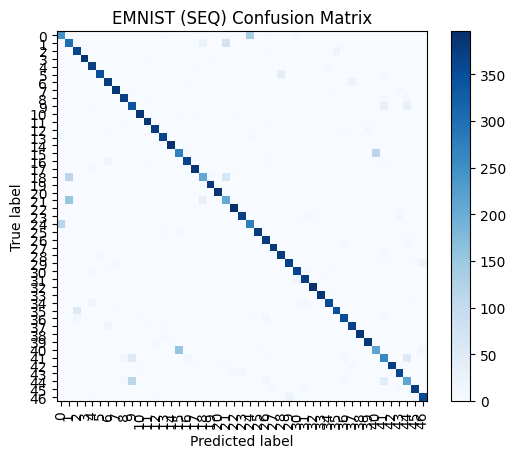

In [176]:
digit_count = 10

conf_matrix = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=90)

# remove the text annotations
for text in disp.text_.ravel():
    text.set_visible(False)

plt.title("EMNIST (SEQ) Confusion Matrix")
plt.show()
